# Universidad del Gran Rosario — UGR
## Ingeniería del Software · Trabajo Práctico · Grupo 11

**Clasificación de Riesgo Hídrico — Provincia de Buenos Aires**  
* Metodología **CRISP-DM**
* Modelo **Random Forest** ·
* Visualización **GIS Heatmap**

| Integrantes |
|---|
| Amuchástegui, Octavio |
| Cabral, Luciano Federico  |
| Flament, Paola Vanesa |
| Franco, Francisco |
| Martinez, Oscar Aníbal |
| Moyano, José Hernán |
| Olivo, Gabriel |
| Tofalo, Tobías |


> **Docentes:** Ing. Ignacio Sanseovich · Lic. Briant Gauna

---

###**Estudio del Caso**
Este trabajo se basa en la aplicación de una metodología de Minería de Datos y su implementación en una solución de software.

Lo que se espera es que el grupo desarrolle:
* Una metodología clara de cómo se procesarán los datos y su resultado e interpretación.
* Las vistas y montaje de la solución de software que dará vida a esta metodología para conectar el proceso de datos con el usuario final.

Elegiremos trabajar con la Metodología CRISP-DM (Cross-Industry Standard Process for Data Mining).

La entrega constará de:
* Notebook completa.
* El link desde donde se puede acceder al producto de software implementado.

**Obtencion del Dataset**:

Para obtener los datos para este proyecto se utilizo la herramienta de Google Earth Engine, en la cual con un script (Java script), se pudo sacar informacion sobre: el porcentaje de superficie urbana, elevacion media en mentros (sobre el nivel del mar) y pendiente media en grados de cada partido de la provincia de Buenos Aires.



**Script**: https://drive.google.com/file/d/1UH3JqOQNSjb1A2Wqqa4iIClX6QOHV_xF/view?usp=sharing

##**Fases del Trabajo**:

##### Importación de Librerías

In [59]:
import numpy as np
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import nbformat
from urllib.request import urlretrieve
from pathlib import Path
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import  LinearRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
  accuracy_score, f1_score,
  classification_report, confusion_matrix
  )

# Configuraciones generales
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

PROJECT_ROOT: Path = Path.cwd()

RAW_DIR: Path = PROJECT_ROOT / "data" / "raw"
RAW_DIR.mkdir(exist_ok=True,parents=True)

PROCESSED_DIR: Path = PROJECT_ROOT / "data" / "processed"
PROCESSED_DIR.mkdir(exist_ok=True,parents=True)

FIGURES_DIR: Path = PROJECT_ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(exist_ok=True,parents=True)


## Fase #1: Comprensión del Negocio / Business Understanding:
Esta fase inicial se centra en comprender los objetivos y requisitos del proyecto desde una perspectiva de negocio, para luego convertir este conocimiento en una definición del problema de minería de datos y un plan preliminar diseñado para lograr los objetivos.

* Elegí un problema de negocio que puedas resolver con datos. Describilo brevemente.
* ¿Cuál es el objetivo principal del análisis? Elaborá un objetivo general y algunos específicos. Te ayudarán a clasificar las tareas más adelante.
* Enumerá los distintos Stakeholders del negocio donde está inmerso el problema.
* ¿Qué impacto tendrá la solución en el negocio o en la toma de decisiones? Justificála realización del estudio desde la perspectiva de cada Stakeholder enumerado anteriormente.

### Caso seleccionado: Priorización de riesgo hídrico por partido (PBA)

**Problema de negocio**
- Los municipios y Defensa Civil no cuentan con una priorización cuantitativa única para decidir dónde invertir primero en mitigación hídrica.

**Objetivo general**
- Construir un modelo de clasificación que asigne nivel de vulnerabilidad a inundaciones por partido de la Provincia de Buenos Aires.

**Objetivos específicos (3)**
- Medir el aporte de factores físico-territoriales: impermeabilización, elevación y pendiente.
- Clasificar partidos en riesgo `bajo`, `medio` o `alto` para priorización operativa.
- Entregar evidencia visual y métricas para justificar decisiones de inversión.

**Stakeholders e impacto**

| Stakeholder | Necesidad | Impacto esperado |
|---|---|---|
| Defensa Civil PBA | Priorizar prevención y respuesta | Menor tiempo de reacción y mejor asignación de recursos |
| Municipios | Planificar obras y ordenamiento territorial | Inversión focalizada en zonas críticas |
| Obras Públicas | Definir cartera de proyectos hídricos | Mejor retorno social del presupuesto |
| Ciudadanía | Transparencia del riesgo local | Mayor preparación comunitaria |
| Academia/Analistas | Marco reproducible para mejorar modelos | Base técnica para iteraciones futuras |

**Decisiones habilitadas por el modelo y KPIs sugeridos**

| Stakeholder | Decisión que habilita el modelo | KPI sugerido |
|---|---|---|
| Defensa Civil PBA | Pre-posicionamiento de recursos | % recursos asignados a partidos de alto riesgo |
| Municipios | Priorización de obras locales | % obras ejecutadas en partidos priorizados |
| Obras Públicas | Asignación de presupuesto anual | % presupuesto en zonas críticas |
| Ciudadanía | Preparación comunitaria | % población cubierta por alertas |
| Academia/Analistas | Mejora metodológica | AUC/F1 en iteraciones futuras |

---

##Fase #2: Comprensión de los Datos / Data Understanding

**Estrategia de adquisición**
- Fuente primaria: dataset local `porc de suelo impermeable, elevacion y pendiente.csv`.
- Estrategia Colab: detectar rutas posibles (`/content/data/raw` o ruta local del repo) y cargar automáticamente.
- Alternativa: descarga automática por URL con `urllib` (sin dependencia de `!wget`).

**Calidad de datos (nulos/ruido)**
- Nulos: imputación por mediana en variables numéricas.
- Duplicados: eliminación por `partido`.
- Ruido/extremos: winsorización por percentiles 1 y 99.

**Tareas CRISP-DM en esta fase**
- Recolección y validación de esquema.
- Perfilado inicial (`shape`, tipos, nulos, descriptivos).
- Definición de variable objetivo proxy para modelado supervisado.
- Registro de supuestos y limitaciones.

## Dataset

El dataset fue descargado y modificado de la plataforma **"MapBiomas"**

**Columna** | **Significado probable**
--------|---------------------
partido | División político-administrativa de la Provincia de Buenos Aires (equivalente a municipio)
porc_urbano | Porcentaje del área del partido clasificada como suelo urbano (según los mapas de MapBiomas)
elev_media | Elevación media del territorio del partido en metros sobre el nivel del mar (derivada de un DEM, modelo digital de elevación)pend_media | Pendiente media del terreno en el partido, en grados o porcentaje (también derivada del DEM)

In [2]:
DATASET_NAME = "porc de suelo impermeable, elevacion y pendiente.csv"
DATASET_URL = "https://raw.githubusercontent.com/oskartinez/risk_pba/main/content/risk_pba/data/raw/porc%20de%20suelo%20impermeable%2C%20elevacion%20y%20pendiente.csv"

urlretrieve(DATASET_URL, RAW_DIR / DATASET_NAME)

df = pd.read_csv(RAW_DIR / DATASET_NAME, sep=',', encoding='latin1', engine='python')
df.columns = [c.strip().lower().replace(" ", "_") for c in df.columns]
df = df.drop_duplicates(subset=["partido"])
df.head(5)

,partido,porc_urbano,elev_media,pend_media
0,Florencio Varela,49.693605,23.384546,2.105181
1,Presidente Peron,25.256499,26.863023,2.382762
2,San Vicente,7.054575,22.218826,2.061773
3,Canuelas,3.290213,28.832046,2.046126
4,Esteban Echeverria,60.158483,18.968620,2.506507


In [3]:
# Datos estadísticos
df.describe()

,porc_urbano,elev_media,pend_media
count,134.000000,134.000000,134.000000
mean,15.851949,60.810925,2.137421
std,29.317177,60.707824,0.508199
min,0.052764,1.409934,1.453510
25%,0.346116,19.990740,1.777499
50%,0.884253,36.932577,2.011081
75%,11.095377,89.805545,2.443820
max,99.596296,319.166680,3.812423


### Imputación

- Asignamos media de la columna a cada valor faltante de las variables numéricas
- Cortamos los valores inferiores o superiores al percentil 1 y 99 respectivamente para evitar outñiers.


In [4]:

num_cols = df.select_dtypes(include=[np.number]).columns
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())
    p1, p99 = df[col].quantile([0.01, 0.99])
    df[col] = df[col].clip(lower=p1, upper=p99)

Fabricamos las etiquetas de la varibale target de forma que nos quede el dataset bien balanceado.

In [5]:
def helper_norm(s):
    rng = s.max() - s.min()
    return (s - s.min()) / rng if rng > 0 else s * 0

df["risk_score"] = (
    0.5 * helper_norm(df["porc_urbano"])
    + 0.3 * helper_norm(df["pend_media"])
    + 0.2 * (1 - helper_norm(df["elev_media"]))
)
df["risk_level"] = pd.qcut(df["risk_score"], q=3, labels=["bajo", "medio", "alto"])
df["risk_level"].value_counts().sort_index()


,count
risk_level,
bajo,45
medio,44
alto,45


Persistencia

In [6]:
clean_path = PROCESSED_DIR / "dataset_clean_proxy.csv"
df.to_csv(clean_path, index=False, encoding="utf-8")

In [7]:


print(" Dataset cargado y procesado")
print(f"   Fuente    : {(RAW_DIR / DATASET_NAME).name}")
print(f"   Registros : {len(df)} partidos")
print(f"   Columnas  : {df.shape[1]}")
print(f"   Guardado  : data/processed/dataset_clean_proxy.csv")
df.head()

 Dataset cargado y procesado
   Fuente    : porc de suelo impermeable, elevacion y pendiente.csv
   Registros : 134 partidos
   Columnas  : 6
   Guardado  : data/processed/dataset_clean_proxy.csv


,partido,porc_urbano,elev_media,pend_media,risk_score,risk_level
0,Florencio Varela,49.693605,23.384546,2.105181,0.529797,alto
1,Presidente Peron,25.256499,26.863023,2.382762,0.441369,alto
2,San Vicente,7.054575,22.218826,2.061773,0.305441,alto
3,Canuelas,3.290213,28.832046,2.046126,0.278710,medio
4,Esteban Echeverria,60.158483,18.968620,2.506507,0.644556,alto


---

##Fase #3: Preparación de los Datos / Data Preparation

**Diccionario de variables**
- `partido`: nombre del partido (categórica nominal).
- `porc_urbano`: porcentaje de suelo impermeabilizado (numérica continua).
- `elev_media`: elevación media (numérica continua).
- `pend_media`: pendiente media (numérica continua).
- `risk_score`: índice compuesto de riesgo (numérica continua, derivada).
- `risk_level`: nivel de riesgo objetivo (`bajo`, `medio`, `alto`).

**EDA planificado**
- Histogramas: distribución de variables numéricas.
- Boxplots: outliers por variable.
- Correlación: matriz para relación entre predictores y `risk_score`.

### Histogramas

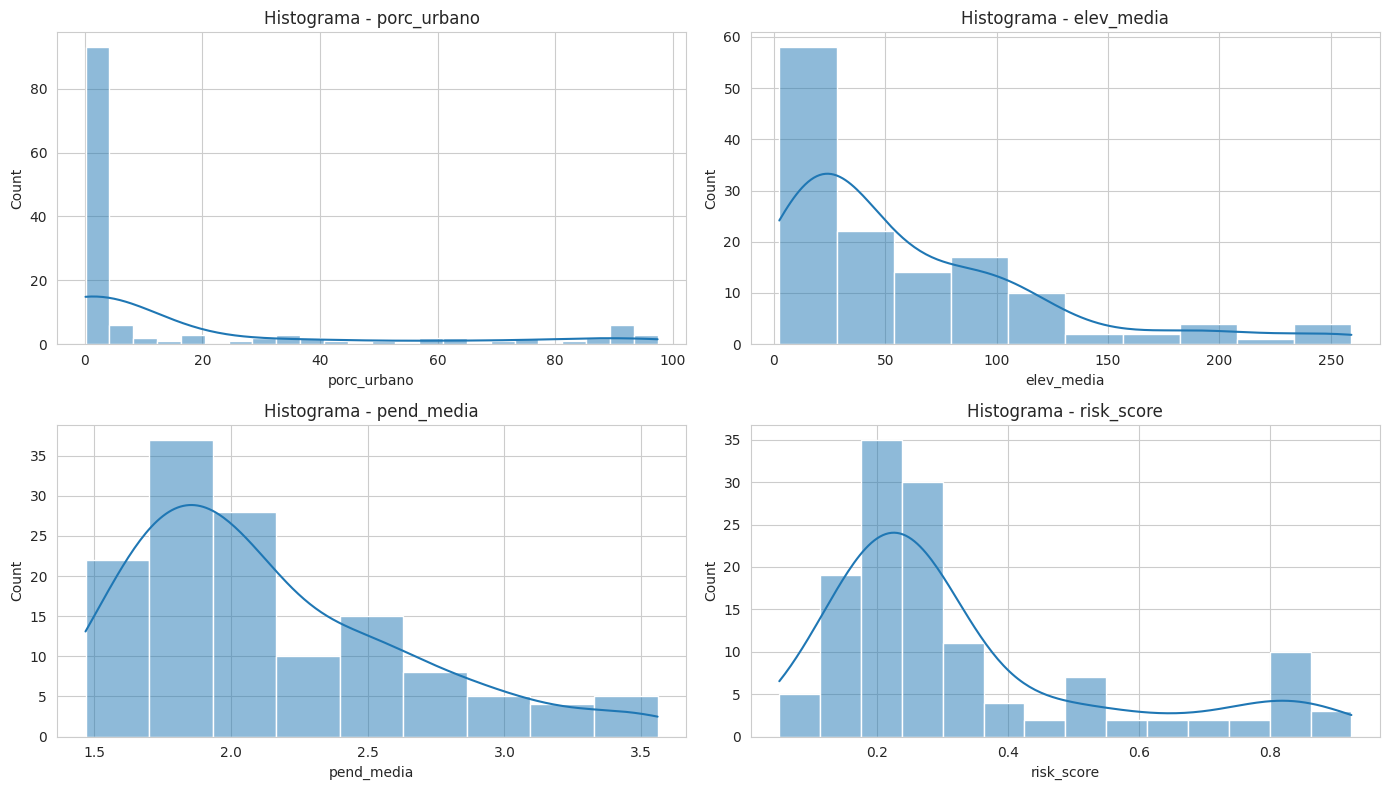

In [28]:
numeric_cols = [x for x in df.select_dtypes(include=[np.number]).columns]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, col in zip(axes.flatten(), numeric_cols):
    sns.histplot(df[col], kde=True, ax=ax, color="#1f77b4")
    ax.set_title(f"Histograma - {col}")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "eda_histograms.png", dpi=150, bbox_inches="tight")
plt.show()

### Boxplots

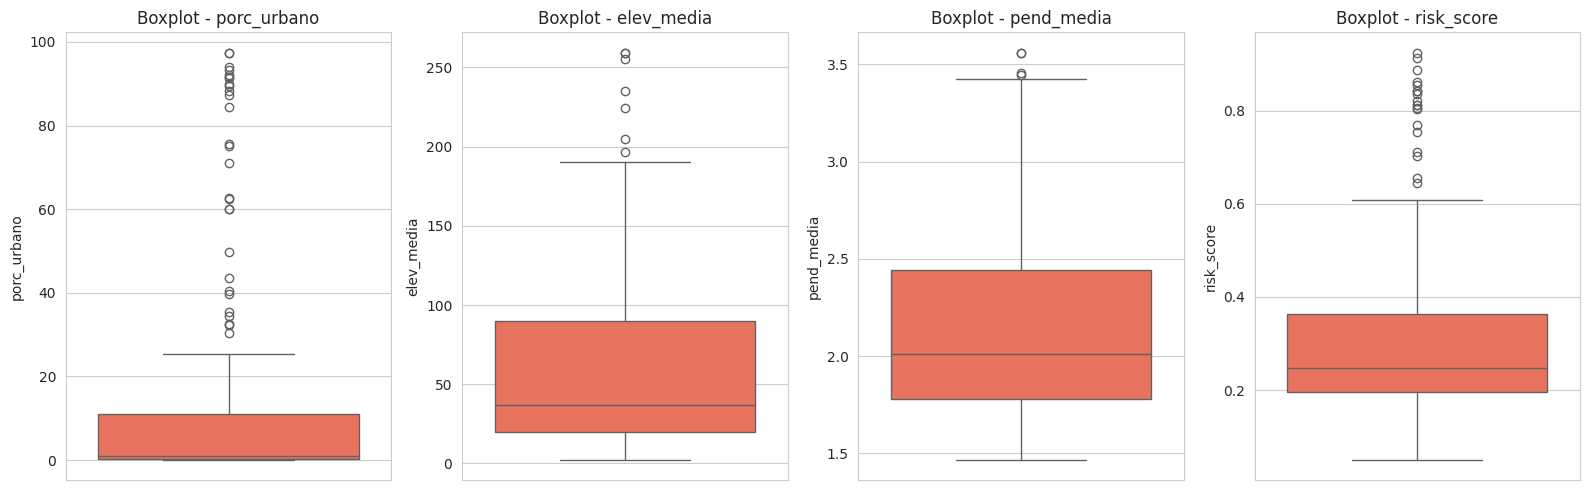

In [23]:
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
for ax, col in zip(axes.flatten(), numeric_cols):
    sns.boxplot(y=df[col], ax=ax, color="tomato")
    ax.set_title(f"Boxplot - {col}")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "eda_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()

### Matriz de correlación

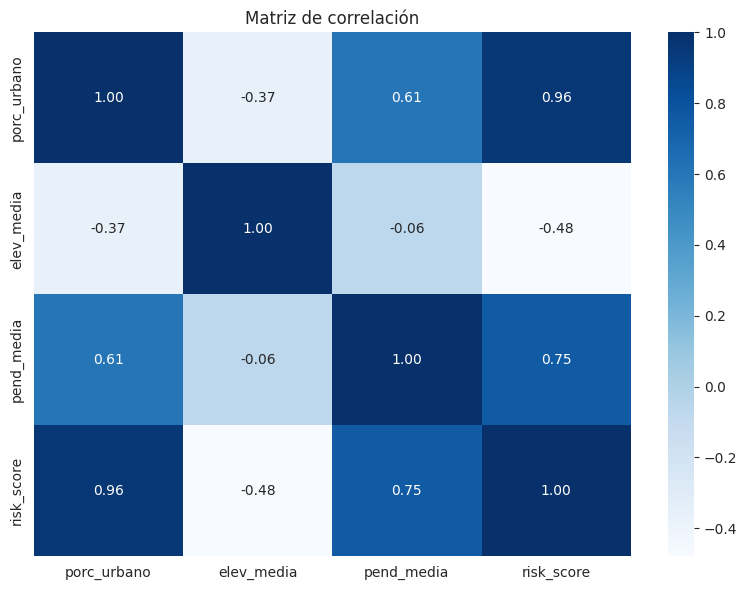

Figuras EDA guardadas en: /content/reports/figures


In [26]:
corr = df[numeric_cols].corr()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="Blues", fmt=".2f", ax=ax)
ax.set_title("Matriz de correlación")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "eda_correlation_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Figuras EDA guardadas en: {FIGURES_DIR}")

### GIS: Mapa de calor de riesgo por partido

- Se construye un mapa de calor geográfico (`density_mapbox`) ponderado por `risk_score`.
- Para georreferenciar, se usa caché en `data/processed/partido_coords.csv`.
- Si el caché no existe, se geocodifica cada partido con `Nominatim` y luego se persiste.
- El resultado se exporta en `reports/figures/gis_heatmap_risk.html`.

In [36]:
# GIS heatmap por partido con caché de coordenadas

coords_cache = PROCESSED_DIR / "partido_coords.csv"

if not coords_cache.exists():
  geolocator = Nominatim(user_agent="risk_pba_gis")
  geocode = RateLimiter(geolocator.geocode, min_delay_seconds=1)
  partidos = sorted(df["partido"].dropna().unique().tolist())

  rows = []
  for p in partidos:
      query = f"{p}, Provincia de Buenos Aires, Argentina"
      loc = geocode(query)
      rows.append(
          {
              "partido": p,
              "lat": np.nan if loc is None else loc.latitude,
              "lon": np.nan if loc is None else loc.longitude,
          }
      )

  coords_df = pd.DataFrame(rows)
  coords_df.to_csv(coords_cache, index=False, encoding="utf-8")
  print(f"Coordenadas persistidas en: {coords_cache}")

coords_df = pd.read_csv(coords_cache)
print(f"Coordenadas cargadas desde caché: {coords_cache}")


Coordenadas persistidas en: /content/data/processed/partido_coords.csv
Coordenadas cargadas desde caché: /content/data/processed/partido_coords.csv


#### Dataset vpara mapas

In [47]:
map_df = df.merge(coords_df, on="partido", how="left")
map_df = map_df.dropna(subset=["lat", "lon", "risk_score"]).copy()

En el mapa de calor vemos donde se ubican las zoinas estudiadas y la cercanía entre ellas.  

In [41]:
fig_heat = px.density_mapbox(
        map_df,
        lat="lat",
        lon="lon",
        z="risk_score",
        radius=22,
        center={"lat": map_df["lat"].mean(), "lon": map_df["lon"].mean()},
        zoom=5.7,
        mapbox_style="carto-positron",
        hover_name="partido",
        hover_data={"risk_score": ":.2f", "porc_urbano": ":.1f", "elev_media": ":.1f", "pend_media": ":.1f"},
        title="GIS Heatmap - Vulnerabilidad hídrica por partido (PBA)",
    )
heatmap_html_path = FIGURES_DIR / "gis_heatmap_risk.html"
fig_heat.write_html(str(heatmap_html_path))
print(f"Mapa GIS exportado en: {heatmap_html_path}")
fig_heat.show()



Mapa GIS exportado en: /content/reports/figures/gis_heatmap_risk.html


En el gráfico de burbvujas le damos color y tamaño por **'risk_score'** .

In [46]:

fig_bubble = px.scatter_mapbox(
        map_df,
        lat="lat",
        lon="lon",
        size="risk_score",
        color="risk_score",
        hover_name="partido",
        hover_data={"risk_score": ":.3f", "porc_urbano": ":.2f", "elev_media": ":.2f", "pend_media": ":.2f"},
        zoom=5.7,
        center={"lat": map_df["lat"].mean(), "lon": map_df["lon"].mean()},
        mapbox_style="carto-positron",
        title="GIS Burbujas - Riesgo por partido (referencia visual)",
    )

bubble_html_path = FIGURES_DIR / "gis_bubble_risk.html"
fig_bubble.write_html(str(bubble_html_path))
print(f"Mapa burbujas exportado en: {bubble_html_path}")

fig_bubble.show()

Mapa burbujas exportado en: /content/reports/figures/gis_bubble_risk.html


---

## Fase #4: Modelado / Modeling

**Algoritmo elegido: Random Forest Classifier**
- Maneja no linealidades sin escalado estricto.
- Es robusto ante ruido moderado y outliers.
- Permite interpretar importancia de variables.

**Variable objetivo**
- `risk_level` (`bajo`, `medio`, `alto`) como clasificación multiclase.

**Predictores**
- `porc_urbano`, `elev_media`, `pend_media`.

In [71]:
# Entrenamiento del modelo

features = ["porc_urbano", "elev_media", "pend_media"]
X = df[features].copy()
y = df["risk_level"].copy()

le = LabelEncoder()
y_enc = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_enc,
    test_size=0.25,
    random_state=42,
    stratify=y_enc,
)

model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    max_depth=6,
    class_weight="balanced",
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

importances = pd.DataFrame(
    {
        "feature": features,
        "importance": model.feature_importances_,
    }
).sort_values("importance", ascending=False)

# Persistencia en data/processed
importances.to_csv(PROCESSED_DIR / "feature_importances.csv", index=False)

with open(PROCESSED_DIR / "rf_risk_model.pkl", "wb") as f:
    pickle.dump(model, f)

with open(PROCESSED_DIR / "label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)

df_scored = df.copy()
df_scored["risk_level_pred"] = le.inverse_transform(model.predict(X))
df_scored.sort_values("risk_score", ascending=False).to_csv(
    PROCESSED_DIR / "risk_ranking.csv", index=False, encoding="utf-8"
)

print(f"Artefactos guardados en: {PROCESSED_DIR}")
importances.sort_values("importance", ascending=False)

Artefactos guardados en: /content/data/processed


,feature,importance
2,pend_media,0.382683
0,porc_urbano,0.326433
1,elev_media,0.290884


---

##Fase #5: Evaluación / Evaluation

**Métricas seleccionadas**
- Accuracy: proporción global de aciertos.
- F1-Score macro: balance entre precisión y recall por clase.
- Matriz de confusión: identifica en qué clases falla el modelo.

> Nota metodológica: al ser clasificación multiclase, no aplica RMSE como métrica principal.

Accuracy: 0.912
F1 macro: 0.907

Classification report:

              precision    recall  f1-score   support

        alto       1.00      1.00      1.00        12
        bajo       0.79      1.00      0.88        11
       medio       1.00      0.73      0.84        11

    accuracy                           0.91        34
   macro avg       0.93      0.91      0.91        34
weighted avg       0.93      0.91      0.91        34



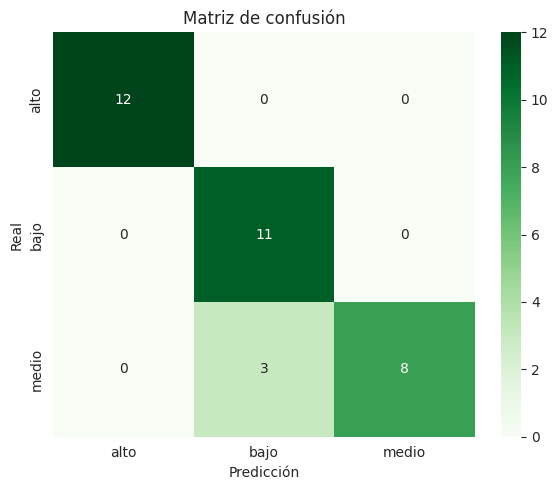

Métricas guardadas en: /content/data/processed/metrics.csv
Matriz guardada en: /content/reports/figures/confusion_matrix.png


In [72]:
# Métricas y matriz de confusión
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average="macro")

print(f"Accuracy: {acc:.3f}")
print(f"F1 macro: {f1:.3f}\n")
print("Classification report:\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))

metrics_df = pd.DataFrame([{"accuracy": acc, "f1_macro": f1}])
metrics_df.to_csv(PROCESSED_DIR / "metrics.csv", index=False)

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    ax=ax,
)
ax.set_xlabel("Predicción")
ax.set_ylabel("Real")
ax.set_title("Matriz de confusión")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Métricas guardadas en: {PROCESSED_DIR / 'metrics.csv'}")
print(f"Matriz guardada en: {FIGURES_DIR / 'confusion_matrix.png'}")

---

##Fase #6: Despliegue (Deployment)

**Plan de mantenimiento**
- Frecuencia de actualización: mensual o trimestral según disponibilidad de datos.
- Monitoreo de performance: `Accuracy` y `F1 macro` por versión.
- Control de drift: comparar distribución de `porc_urbano`, `elev_media`, `pend_media` vs. entrenamiento.
- Gobernanza: versionado de dataset, modelo y notebook (Git + etiqueta de release).

**Estructura de carpetas del proyecto (operativa)**
- `data/raw`: entrada de datos fuente.
- `data/processed`: artefactos del modelo (`rf_risk_model.pkl`, `label_encoder.pkl`, `metrics.csv`, `risk_ranking.csv`).
- `reports/figures`: visuales exportadas (`confusion_matrix.png`, `feature_importances.png`).
- `src`: scripts de pipeline, entrenamiento y app.

**Arquitectura sugerida (Streamlit)**
1. Ingesta: CSV actualizado en `data/raw`.
2. Procesamiento: pipeline de limpieza + cálculo de `risk_score`.
3. Inferencia: modelo Random Forest serializado (`pkl`).
4. App Streamlit:
   - Selector de partido.
   - Visual de nivel de riesgo.
   - Importancia de variables.
5. Publicación: Streamlit Community Cloud o servidor institucional.

**Comandos sugeridos**
- `python src/train_model.py`
- `streamlit run src/app_streamlit.py`

**Vista mínima de la app**
- Panel 1: Ranking de partidos por riesgo.
- Panel 2: Ficha del partido seleccionado.
- Panel 3: Matriz de confusión y métricas del último entrenamiento.

### Backlog de mejora continua

- Integrar precipitación extrema histórica (SMN/INA).
- Integrar exposición poblacional y NBI por partido.
- Reemplazar target proxy por eventos reales de inundación.
- Incorporar validación temporal para robustez operativa.